In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
#Read the data from csv
df_subject = pd.read_csv('subject-info.csv')
df_test = pd.read_csv('test_measure.csv')

#Exclude warm up phase
df_test_excludewarmup =df_test[ df_test['Speed'] > 5].copy()

#Merge 2 datsets on participant ID
df_merge = pd.merge(df_subject,df_test, on='ID')

In [27]:
#Q.1 Performance Consistency: Identify athletes whose heart rate (HR) varies the least during the entire test.

# Extract base ID from ID_test (everything before the underscore)
df_test_excludewarmup['Athlete_ID'] = df_test_excludewarmup['ID_test'].apply(lambda x: x.split('_')[0])

# Standard deviation of HR per athlete
hr_variation = df_test_excludewarmup.groupby(['Athlete_ID'])['HR'].std().reset_index()
hr_variation.columns = ['Athlete_ID', 'HR_StdDev']

# Round to 2 decimal places
hr_variation['HR_StdDev'] = hr_variation['HR_StdDev'].round(2)

# Sort by least variation, Lower the STD = more consistent
least_hr = hr_variation.sort_values('HR_StdDev')

display(least_hr.style.hide(axis='index').format({'HR_StdDev': '{:.1f}'}))


Athlete_ID,HR_StdDev
817,6.0
144,9.1
486,9.2
645,10.2
9,11.8
246,11.9
414,12.1
213,12.2
318,12.7
250,12.9


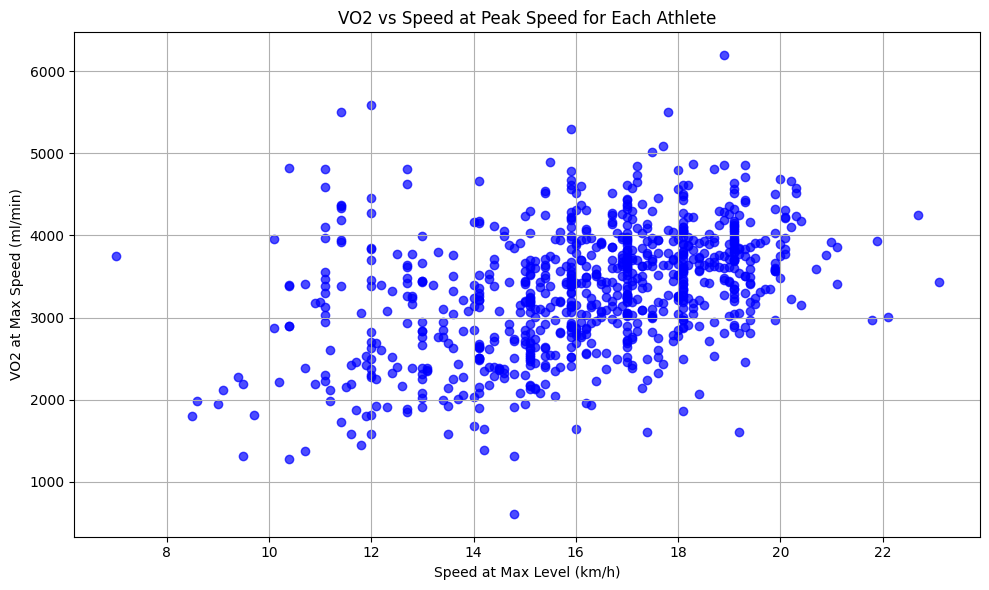

In [39]:
#Q2. Efficiency at Peak Speed: Identify the efficiency (VO2 and VE) at peak speed for each athlete.

# Get the rows where Speed is maximum for each ID
df_peak_speed_data = df_test.loc[df_test.groupby('ID')['Speed'].idxmax()].copy()


plt.figure(figsize=(10, 6))
plt.scatter(df_peak_speed_data['Speed'], df_peak_speed_data['VO2'], color='blue', alpha=0.7)
plt.title('VO2 vs Speed at Peak Speed for Each Athlete')
plt.xlabel('Speed at Max Level (km/h)')
plt.ylabel('VO2 at Max Speed (ml/min)')
plt.grid(True)
plt.tight_layout()
plt.show()


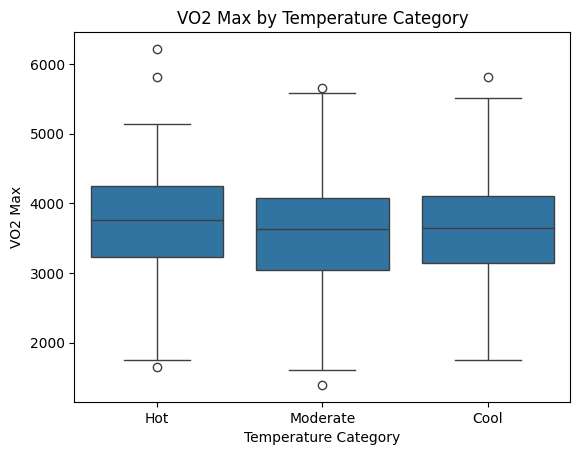

In [ ]:
#Q.3 Categorize by Temperature and Compare VO2 Max
#(Assumption: Temp < 20°C = Cool, 20-25 = Moderate, >25 = Hot.)



# Create temperature categories
def categorize_temp(temp):
    if temp < 20:
        return 'Cool'
    elif 20 <= temp <= 25:
        return 'Moderate'
    else:
        return 'Hot'

df_subject['Temp_Category'] = df_subject['Temperature'].apply(categorize_temp).copy()

test_temp_category = pd.merge(df_test, df_subject[['ID', 'Temp_Category']], on='ID')

# Max VO2 per test
vo2_max = test_temp_category.groupby(['ID', 'Temp_Category'])['VO2'].max().reset_index()

# Plot
sns.boxplot(data=vo2_max, x='Temp_Category', y='VO2')
plt.title('VO2 Max by Temperature Category')
plt.xlabel('Temperature Category')
plt.ylabel('VO2 Max')
plt.show()
